# Deep Dive: Discrete-Time LTI Identification

This notebook compares two Bayesian parameterizations for a discrete-time linear time-invariant (LTI) state-space model in `dynestyx`:

1. **Standard form** (directly sample entries of `A, B, C`)
2. **Canonical form** (sample companion coefficients uniformly in the stability triangle)

We focus on:

- parameter recovery,
- predictive performance,
- stability behavior,
- and practical identifiability differences.

The setup is:

- state dimension `d_x = 2`
- control dimension `d_u = 1`
- observation dimension `d_y = 1`
- no biases, and `D = 0`
- `x_0 ~ N(0, I)`
- process noise `Q = sigma_state^2 I`
- observation noise `R = sigma_obs^2 I`
- sequence length `T = 400`
- controls `u_t ~ N(0, 1)` iid.

## Imports and global configuration

We use:

- `dynestyx` for simulation and exact Kalman-filter marginalization,
- `numpyro`/`jax` for Bayesian inference,
- `matplotlib` for diagnostics and posterior plots.

For parallel chains on CPU, this notebook sets host device count before JAX is initialized. If you change `NUM_CHAINS`, restart the kernel and rerun from the top.

In [1]:
import os

# Inference config (set chains before importing JAX so parallel host devices can be created)
NUM_CHAINS = 4
os.environ.setdefault(
    'XLA_FLAGS',
    f'--xla_force_host_platform_device_count={8}',
)

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, Filter, LTI_discrete
from dynestyx.inference.filter_configs import KFConfig, EKFConfig, UKFConfig

# Problem dimensions
STATE_DIM = 2
CONTROL_DIM = 1
OBS_DIM = 1
T = 50

# Prior support for canonical eigenvalue prior
LAMBDA_MAX = 0.98

# Inference config (adjust for speed/quality trade-off)
NUM_WARMUP = 50
NUM_SAMPLES = 100

FILTER_SOURCE = 'cuthbert'  # 'cuthbert' or 'dynestyx'

numpyro.set_host_device_count(8)
print('JAX local_device_count =', jax.local_device_count())
print('Configured NUM_CHAINS =', NUM_CHAINS)

rng = jr.PRNGKey(0)

JAX local_device_count = 8
Configured NUM_CHAINS = 4


## 1) Ground-truth system generation

We generate a stable `A_true` with a **complex-eigenvalue-biased** sampler:

1. with high probability, sample a complex-conjugate pair `r * exp(+- i theta)` inside the unit disk,
2. otherwise sample two real eigenvalues inside the unit disk,
3. sample a random orthogonal matrix `V`,
4. set `A_true = V @ A_canonical @ V.T`.

Then sample `B_true` and `C_true` entrywise from `N(0,1)`, and set fixed known positive noise scales.

This keeps stability while making oscillatory (imaginary-part) dynamics more common.

In [2]:
rng, kA, kB, kC, ku, ksim = jr.split(rng, 6)

A_true = jnp.array([[0.5, -0.3], [0.3, 0.5]])
lam_true = jnp.linalg.eigvals(A_true)
B_true = jr.normal(kB, (STATE_DIM, CONTROL_DIM))
C_true = jr.normal(kC, (OBS_DIM, STATE_DIM))
sigma_state_true = 0.1
sigma_obs_true = 0.1


def standard_to_canonical_transform(A, B, C):
    """Map (A,B,C) to controllable companion coordinates with B_can=[0,1]^T."""
    A_np = np.array(A, dtype=float)
    B_np = np.array(B, dtype=float)
    C_np = np.array(C, dtype=float)

    W = np.concatenate([B_np, A_np @ B_np], axis=1)
    if np.linalg.matrix_rank(W) < STATE_DIM:
        raise ValueError('True (A,B) is not controllable; canonical transform is undefined.')

    # Use Cayley-Hamilton-based basis: T = [A B + a1 B, B], with a1 = -tr(A).
    # This guarantees T^{-1} B = [0,1]^T for controllable (A,B).
    a0 = float(np.linalg.det(A_np))
    a1 = float(-np.trace(A_np))
    t1 = A_np @ B_np + a1 * B_np
    T = np.concatenate([t1, B_np], axis=1)
    if np.linalg.matrix_rank(T) < STATE_DIM:
        raise ValueError('Constructed basis is singular; check controllability and numeric conditioning.')

    T_inv = np.linalg.solve(T, np.eye(STATE_DIM))
    A_can = T_inv @ A_np @ T
    B_can = T_inv @ B_np
    C_can = C_np @ T

    # Target companion form implied by (a0, a1): z^2 + a1 z + a0 = 0
    A_companion_target = np.array([[0.0, 1.0], [-a0, -a1]], dtype=float)
    return A_can, B_can, C_can, T, A_companion_target

# We will use these to visualize correctness of canonical form inference and the transformation.
A_can_true, B_can_true, C_can_true, T_can_true, A_companion_target = standard_to_canonical_transform(
    A_true,
    B_true,
    C_true,
)

Q_true = (sigma_state_true**2) * jnp.eye(STATE_DIM)
R_true = (sigma_obs_true**2) * jnp.eye(OBS_DIM)

obs_times = jnp.arange(T, dtype=jnp.float32)
ctrl_times = obs_times
ctrl_values = 1*jr.normal(ku, (T, CONTROL_DIM))

print('A_true:\n', A_true)
print('eig(A_true)=', jnp.linalg.eigvals(A_true))
print('spectral radius(A_true)=', jnp.max(jnp.abs(jnp.linalg.eigvals(A_true))))
print('B_true:\n', B_true)
print('C_true:\n', C_true)
print('A_true in canonical coordinates:\n', A_can_true)
print('Companion target from invariants:\n', A_companion_target)
print('A_can - target:\n', A_can_true - A_companion_target)
print('B_true in canonical coordinates (target [0,1]^T):\n', B_can_true)
print('C_true in canonical coordinates [C0, C1]:\n', C_can_true)

A_true:
 [[ 0.5 -0.3]
 [ 0.3  0.5]]
eig(A_true)= [0.5+0.3j 0.5-0.3j]
spectral radius(A_true)= 0.5830952
B_true:
 [[1.2956359]
 [1.3550105]]
C_true:
 [[-0.6219436  0.6248041]]
A_true in canonical coordinates:
 [[-2.54941527e-17  1.00000000e+00]
 [-3.40000007e-01  1.00000000e+00]]
Companion target from invariants:
 [[ 0.          1.        ]
 [-0.34000001  1.        ]]
A_can - target:
 [[-2.54941527e-17  2.22044605e-16]
 [-5.55111512e-17  2.22044605e-16]]
B_true in canonical coordinates (target [0,1]^T):
 [[0.]
 [1.]]
C_true in canonical coordinates [C0, C1]:
 [[0.47527583 0.04080362]]


In [3]:
def lti_forward_model(A, B, C, sigma_state, sigma_obs, obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None):
    """Shared dynestyx LTI model with D=0 and no biases."""
    Q = (sigma_state**2) * jnp.eye(STATE_DIM)
    R = (sigma_obs**2) * jnp.eye(OBS_DIM)
    D = jnp.zeros((OBS_DIM, CONTROL_DIM))
    dynamics = LTI_discrete(
        A=A,
        Q=Q,
        H=C,
        R=R,
        B=B,
        D=D,
        initial_mean=jnp.zeros(STATE_DIM),
        initial_cov=jnp.eye(STATE_DIM),
    )
    return dsx.sample(
        'f',
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )


def true_data_model(obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None):
    return lti_forward_model(
        A=A_true,
        B=B_true,
        C=C_true,
        sigma_state=sigma_state_true,
        sigma_obs=sigma_obs_true,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )


pred_true = Predictive(true_data_model, num_samples=1, exclude_deterministic=False)
with DiscreteTimeSimulator():
    synthetic = pred_true(ksim, obs_times=obs_times, ctrl_times=ctrl_times, ctrl_values=ctrl_values)

x_true = synthetic['states'][0]          # (T, 2)
y_obs = synthetic['observations'][0]     # (T, 1)

print('x_true shape:', x_true.shape)
print('y_obs shape:', y_obs.shape)

x_true shape: (50, 2)
y_obs shape: (50, 1)


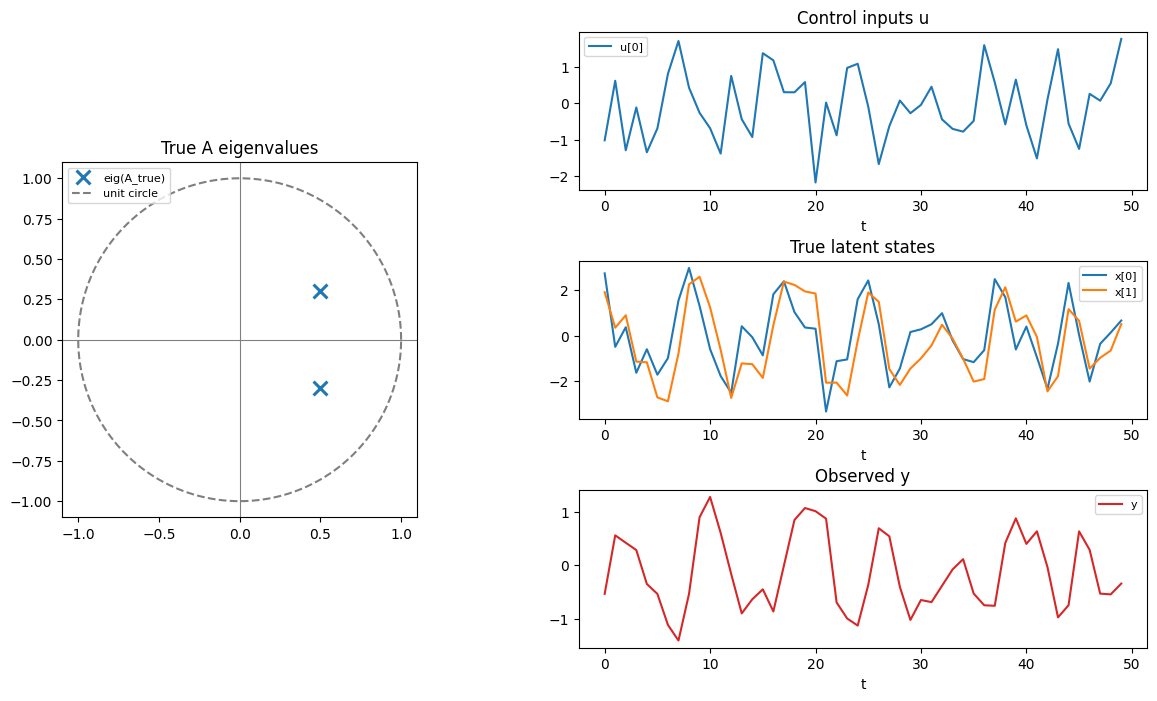

In [4]:
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(3, 2, width_ratios=[1, 1.6], hspace=0.45, wspace=0.35)

# Left column: eigenvalue plot (spans all 3 rows)
ax_eig = fig.add_subplot(gs[:, 0])
lam_plot = np.array(jnp.linalg.eigvals(A_true))
ax_eig.scatter(
    lam_plot.real,
    lam_plot.imag,
    c='C0',
    s=100,
    marker='x',
    linewidths=2.2,
    label='eig(A_true)',
)
theta = np.linspace(0, 2 * np.pi, 200)
ax_eig.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.5, label='unit circle')
ax_eig.axhline(0.0, color='gray', lw=0.8)
ax_eig.axvline(0.0, color='gray', lw=0.8)
ax_eig.set_aspect('equal', 'box')
ax_eig.set_title('True A eigenvalues')
ax_eig.legend(fontsize=8, loc='upper left')

# Right column, top: control inputs
ax_u = fig.add_subplot(gs[0, 1])
for j in range(ctrl_values.shape[1]):
    ax_u.plot(np.array(ctrl_values[:, j]), label=f'u[{j}]')
ax_u.set_title('Control inputs u')
ax_u.set_xlabel('t')
ax_u.legend(fontsize=8)

# Right column, middle: true latent states
ax_x = fig.add_subplot(gs[1, 1])
ax_x.plot(np.array(x_true[:, 0]), label='x[0]')
ax_x.plot(np.array(x_true[:, 1]), label='x[1]')
ax_x.set_title('True latent states')
ax_x.set_xlabel('t')
ax_x.legend(fontsize=8)

# Right column, bottom: observed y
ax_y = fig.add_subplot(gs[2, 1])
ax_y.plot(np.array(y_obs[:, 0]), color='C3', label='y')
ax_y.set_title('Observed y')
ax_y.set_xlabel('t')
ax_y.legend(fontsize=8)

plt.show()

## 2) Two Bayesian model parameterizations
- Model 1 (standard form)
- Model 2 (canonical form)

### Model 1: Standard form

Sample all entries of `A, B, C` directly with i.i.d. Normal priors. Noise scales are treated as known constants.

In [5]:
def enforce_lambda_max(A, lambda_max=LAMBDA_MAX):
    """
    Rescale A toward zero iff its spectral radius exceeds lambda_max.

    If rho(A) <= lambda_max the matrix is returned unchanged.
    Otherwise A is multiplied by lambda_max / rho(A), which maps every
    eigenvalue magnitude to exactly lambda_max while preserving direction.
    The operation is smooth everywhere except at rho = lambda_max (a
    measure-zero set), so gradients are well-behaved during HMC.
    """
    eigvals = jnp.linalg.eigvals(A.astype(jnp.complex64))
    rho = jnp.max(jnp.abs(eigvals))
    scale = jnp.minimum(jnp.ones(()), lambda_max / rho)
    return A * scale


def standard_model(obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None):
    """Direct parameterization: A, B, C entries have iid Normal priors."""
    A_raw = numpyro.sample('A', dist.Normal(0.0, 1.0).expand([STATE_DIM, STATE_DIM]).to_event(2))
    A = enforce_lambda_max(A_raw)
    B = numpyro.sample('B', dist.Normal(0.0, 1.0).expand([STATE_DIM, CONTROL_DIM]).to_event(2))
    C = numpyro.sample('C', dist.Normal(0.0, 1.0).expand([OBS_DIM, STATE_DIM]).to_event(2))

    return lti_forward_model(
        A=A,
        B=B,
        C=C,
        sigma_state=sigma_state_true,
        sigma_obs=sigma_obs_true,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )


### Model 2: Canonical form with a stability-triangle prior

Use a 2D companion matrix

$$
A = \begin{bmatrix}
0 & 1 \\
-a_0 & -a_1
\end{bmatrix}
$$

and place a **uniform prior** on `(a0, a1)` over the discrete-time stability triangle:

$$
|a_0| < 1,
\qquad
|a_1| < 1 + a_0.
$$

This is the standard Schur-stability region for second-order real polynomials and guarantees stable eigenvalues for the companion `A`.

It also corresponds to a particular mixture distribution over real/complex eigenvalues for `A` (see Lemma 4.3 in [Bryutkin et al.](https://arxiv.org/abs/2507.11535))

In [6]:
def canonical_companion_A(a0, a1):
    """2x2 companion matrix with coefficients from characteristic polynomial."""
    return jnp.array([[0.0, 1.0], [-a0, -a1]])


def sample_uniform_stability_triangle():
    """Uniform sample on triangle vertices (-1,0), (1,2), (1,-2)."""
    u = numpyro.sample('tri_u', dist.Uniform(0.0, 1.0))
    v = numpyro.sample('tri_v', dist.Uniform(0.0, 1.0))
    # Reflect to get uniform barycentric coordinates on the reference simplex
    u_ref = jnp.where(u + v > 1.0, 1.0 - u, u)
    v_ref = jnp.where(u + v > 1.0, 1.0 - v, v)

    v0 = jnp.array([-1.0, 0.0])
    v1 = jnp.array([1.0, 2.0])
    v2 = jnp.array([1.0, -2.0])
    point = v0 + u_ref * (v1 - v0) + v_ref * (v2 - v0)
    return point[0], point[1]


def canonical_model(obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None):
    """Canonical parameterization: learn a0, a1, C with known noise scales."""
    a0, a1 = sample_uniform_stability_triangle()

    A = enforce_lambda_max(canonical_companion_A(a0, a1))
    B = jnp.array([[0.0], [1.0]])
    C = numpyro.sample('C', dist.Normal(0.0, 1.0).expand([OBS_DIM, STATE_DIM]).to_event(2))

    numpyro.deterministic('a0', a0)
    numpyro.deterministic('a1', a1)

    # Call the forward model to get the likelihood
    lti_forward_model(
        A=A,
        B=B,
        C=C,
        sigma_state=sigma_state_true,
        sigma_obs=sigma_obs_true,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )

    # Compute and store quantitites of interest for later visualization
    # Complex-safe quadratic roots for z^2 + a1 z + a0 = 0
    disc_c = (a1**2 - 4.0 * a0).astype(jnp.complex64)
    sqrt_disc = jnp.sqrt(disc_c)
    lam1 = (-a1 + sqrt_disc) / 2.0
    lam2 = (-a1 - sqrt_disc) / 2.0
    numpyro.deterministic('lambda1_real', jnp.real(lam1))
    numpyro.deterministic('lambda1_imag', jnp.imag(lam1))
    numpyro.deterministic('lambda2_real', jnp.real(lam2))
    numpyro.deterministic('lambda2_imag', jnp.imag(lam2))
    numpyro.deterministic('A', A)
    numpyro.deterministic('B', B)
    

## 3) Posterior inference with exact KF-marginalized likelihood

We now run inference in two clearly separated phases:

1. **Standard-form run** (`A, B, C` learned directly).
2. **Canonical-form run** (`a0, a1, C` learned, with fixed companion structure).

Both use `NUTS` with `Filter(KFConfig())` and are conditioned on the same observations `y_obs` and control sequence `ctrl_values`.

Because the model is linear-Gaussian conditional on parameters, latent states are marginalized exactly via Kalman filtering.

### 3) Posterior runs

In [7]:
def make_conditioned_model(base_model, y):
    def conditioned_model():
        with Filter(filter_config=KFConfig(filter_source=FILTER_SOURCE)):
            return base_model(
                obs_times=obs_times,
                obs_values=y,
                ctrl_times=ctrl_times,
                ctrl_values=ctrl_values,
            )

    return conditioned_model


def run_mcmc(model, key, name):
    nuts = NUTS(model)
    mcmc = MCMC(
        nuts,
        num_warmup=NUM_WARMUP,
        num_samples=NUM_SAMPLES,
        num_chains=NUM_CHAINS,
        chain_method='parallel',
    )
    mcmc.run(key, extra_fields=('potential_energy',))
    mcmc.print_summary(exclude_deterministic=False)
    samples = mcmc.get_samples(group_by_chain=False)
    print(f'[{name}] sites:', sorted(samples.keys()))
    return mcmc, samples




Plotters

In [8]:
standard_true_map = {
    'A': np.array(A_true),
    'B': np.array(B_true),
    'C': np.array(C_true),
}


# Full bivariate histograms for each model's learned parameters


def flatten_parameter_block(samples, keys):
    blocks = []
    names = []
    for key in keys:
        if key not in samples:
            continue
        arr = np.array(samples[key])
        if arr.ndim == 1:
            arr = arr[:, None]
            names.append(key)
        else:
            flat = arr.reshape(arr.shape[0], -1)
            arr = flat
            names.extend([f"{key}[{i}]" for i in range(flat.shape[1])])
        blocks.append(arr)
    if not blocks:
        raise ValueError("No matching parameter keys found in samples.")
    return np.concatenate(blocks, axis=1), names


def flatten_true_block(true_map, keys):
    vals = []
    names = []
    for key in keys:
        if key not in true_map:
            continue
        arr = np.array(true_map[key])
        if arr.ndim == 0:
            vals.append(float(arr))
            names.append(key)
        else:
            flat = arr.reshape(-1)
            vals.extend(flat.tolist())
            names.extend([f"{key}[{i}]" for i in range(flat.shape[0])])
    return np.array(vals, dtype=float), names


def build_true_vector(names, true_map, keys):
    vals, val_names = flatten_true_block(true_map, keys)
    name_to_val = {n: v for n, v in zip(val_names, vals)}
    return np.array([name_to_val.get(n, np.nan) for n in names], dtype=float)


def plot_full_bivariate_hist(theta, names, title, cmap='Blues', bins=28, truth_vector=None):
    d = theta.shape[1]
    fig, axs = plt.subplots(d, d, figsize=(2.1 * d, 2.1 * d))

    def _expand_lim_to_include(ax, val, which='x'):
        if not np.isfinite(val):
            return
        if which == 'x':
            lo, hi = ax.get_xlim()
        else:
            lo, hi = ax.get_ylim()
        if lo <= val <= hi:
            return
        span = max(hi - lo, 1e-6)
        pad = 0.08 * span
        new_lo = min(lo, val - pad)
        new_hi = max(hi, val + pad)
        if which == 'x':
            ax.set_xlim(new_lo, new_hi)
        else:
            ax.set_ylim(new_lo, new_hi)

    for i in range(d):
        for j in range(d):
            ax = axs[i, j]
            tx = np.nan if truth_vector is None else truth_vector[j]
            ty = np.nan if truth_vector is None else truth_vector[i]

            if i == j:
                ax.hist(theta[:, j], bins=bins, density=True, color='0.35', alpha=0.8)
                _expand_lim_to_include(ax, tx, which='x')
                if np.isfinite(tx):
                    ymax = ax.get_ylim()[1]
                    ax.scatter(
                        [tx],
                        [0.92 * ymax],
                        marker='x',
                        c='crimson',
                        s=70,
                        linewidths=1.8,
                        zorder=4,
                    )
                    ax.axvline(tx, color='crimson', alpha=0.35, lw=1.0)
            else:
                # Show both lower and upper triangles so truth markers appear in every subplot.
                ax.hist2d(theta[:, j], theta[:, i], bins=bins, cmap=cmap)
                _expand_lim_to_include(ax, tx, which='x')
                _expand_lim_to_include(ax, ty, which='y')
                if np.isfinite(tx) and np.isfinite(ty):
                    ax.scatter(
                        [tx],
                        [ty],
                        marker='x',
                        c='crimson',
                        s=70,
                        linewidths=1.8,
                        zorder=4,
                    )

            if i < d - 1:
                ax.set_xticklabels([])
            else:
                ax.set_xlabel(names[j], fontsize=8, rotation=45, ha='right')
            if j > 0:
                ax.set_yticklabels([])
            else:
                ax.set_ylabel(names[i], fontsize=8)

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

def plot_eigenvalue_posteriors_on_unit_circle(A_std_samples, A_can_samples, A_true_mat):
    eig_std = np.linalg.eigvals(np.array(A_std_samples))
    eig_can = np.linalg.eigvals(np.array(A_can_samples))
    eig_true = np.linalg.eigvals(np.array(A_true_mat))

    fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    theta = np.linspace(0, 2 * np.pi, 400)

    for ax, eig_post, title, color in [
        (axs[0], eig_std, 'Standard posterior eigenvalues', 'C0'),
        (axs[1], eig_can, 'Canonical posterior eigenvalues', 'C1'),
    ]:
        ax.scatter(
            eig_post.real.reshape(-1),
            eig_post.imag.reshape(-1),
            s=8,
            alpha=0.12,
            color=color,
            label='posterior eig cloud',
        )
        ax.scatter(
            eig_true.real,
            eig_true.imag,
            marker='x',
            s=110,
            linewidths=2.2,
            color='crimson',
            label='truth eig(A_true)',
            zorder=4,
        )
        ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.55, label='unit circle')
        ax.axhline(0.0, color='gray', lw=0.8)
        ax.axvline(0.0, color='gray', lw=0.8)
        ax.set_aspect('equal', 'box')
        ax.set_title(title)
        ax.legend(fontsize=8, loc='upper left')

    axs[0].set_xlabel('Re(lambda)')
    axs[0].set_ylabel('Im(lambda)')
    axs[1].set_xlabel('Re(lambda)')
    plt.tight_layout()
    plt.show()


def sample_random_orthogonal_matrices(seed, n, dim=2):
    rng_local = np.random.default_rng(seed)
    z = rng_local.normal(size=(n, dim, dim))
    q, r = np.linalg.qr(z)
    sign = np.sign(np.diagonal(r, axis1=-2, axis2=-1))
    sign[sign == 0.0] = 1.0
    q = q * sign[:, None, :]
    det_q = np.linalg.det(q)
    q[det_q < 0.0, :, 0] *= -1.0
    return q


def pushforward_canonical_to_standard(post_can_samples, n_push=1500, seed=0):
    if 'A' in post_can_samples:
        A_all = np.array(post_can_samples['A'])
    elif 'a0' in post_can_samples and 'a1' in post_can_samples:
        a0_all = np.array(post_can_samples['a0'])
        a1_all = np.array(post_can_samples['a1'])
        A_all = np.stack(
            [
                np.stack([np.zeros_like(a0_all), np.ones_like(a0_all)], axis=-1),
                np.stack([-a0_all, -a1_all], axis=-1),
            ],
            axis=-2,
        )
    else:
        raise KeyError("Need either 'A' or both 'a0'/'a1' in canonical samples.")

    n_total = A_all.shape[0]
    if n_total == 0:
        raise ValueError('Canonical posterior appears empty.')

    n_keep = min(n_total, n_push)
    idx = np.linspace(0, n_total - 1, n_keep, dtype=int)

    A_can = A_all[idx]

    if 'B' in post_can_samples:
        B_can = np.array(post_can_samples['B'])[idx]
    else:
        B_can = np.broadcast_to(np.array([[0.0], [1.0]]), (n_keep, STATE_DIM, CONTROL_DIM))

    if 'C' not in post_can_samples:
        raise KeyError("Need 'C' in canonical samples for push-forward.")
    C_can = np.array(post_can_samples['C'])[idx]

    Q = sample_random_orthogonal_matrices(seed=seed, n=n_keep, dim=STATE_DIM)
    QT = np.transpose(Q, (0, 2, 1))

    A_push = Q @ A_can @ QT
    B_push = Q @ B_can
    C_push = C_can @ QT

    pushed = {
        'A': A_push,
        'B': B_push,
        'C': C_push,
    }
    return pushed


### 3B) Canonical-form posterior run

In this run, `A` is constrained to companion form and effectively parameterized by `(a0, a1)`, while `B` is fixed and only `C` is inferred (with known noise scales).

This separation makes it easier to compare posterior geometry and identifiability against the standard form.

In [9]:
print('\n=== Canonical-form inference (learn a0, a1, C with fixed companion structure) ===')
rng, k_can = jr.split(rng, 2)
can_cond = make_conditioned_model(canonical_model, y_obs)
mcmc_can, post_can = run_mcmc(can_cond, k_can, 'canonical')


=== Canonical-form inference (learn a0, a1, C with fixed companion structure) ===


  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]


                                        mean       std    median      5.0%     95.0%     n_eff     r_hat
                            A[0,0]      0.00      0.00      0.00      0.00      0.00       nan       nan
                            A[0,1]      0.99      0.01      0.99      0.98      1.00       nan      7.69
                            A[1,0]     -0.64      0.34     -0.68     -0.98     -0.28      2.02     14.85
                            A[1,1]     -0.50      1.46     -0.53     -1.96      0.99      2.01     66.85
                            B[0,0]      0.00      0.00      0.00      0.00      0.00       nan       nan
                            B[1,0]      1.00      0.00      1.00      1.00      1.00       nan       nan
                            C[0,0]     -2.24      2.79     -1.83     -5.37      0.59      2.03     10.48
                            C[0,1]      0.48      0.50      0.15     -0.04      1.16      2.31      2.78
                                a0      0.65      0.35

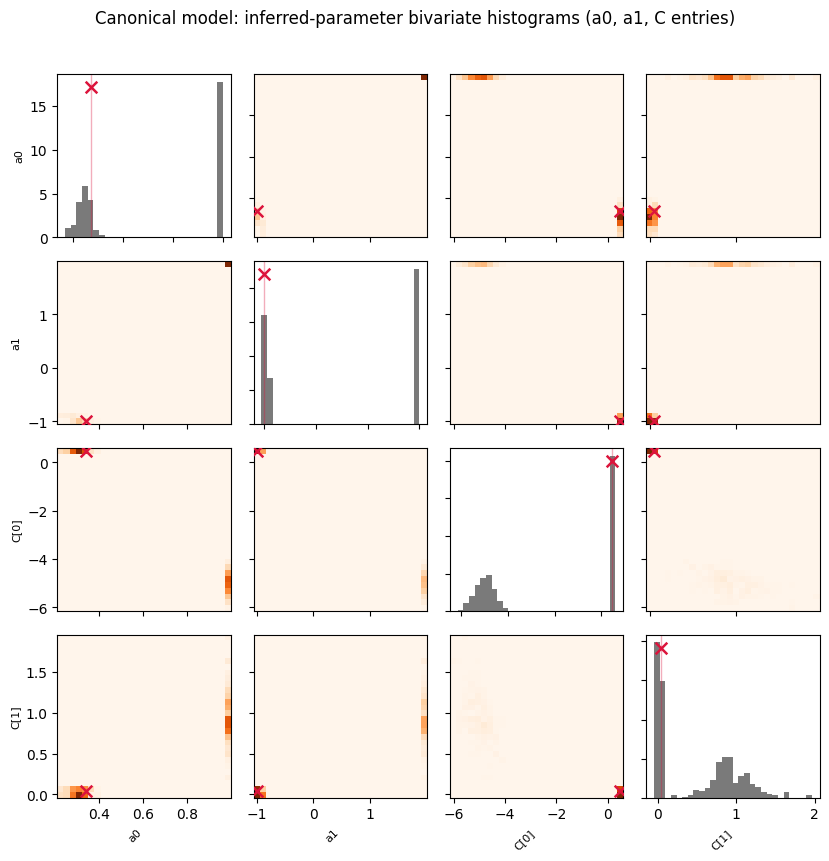

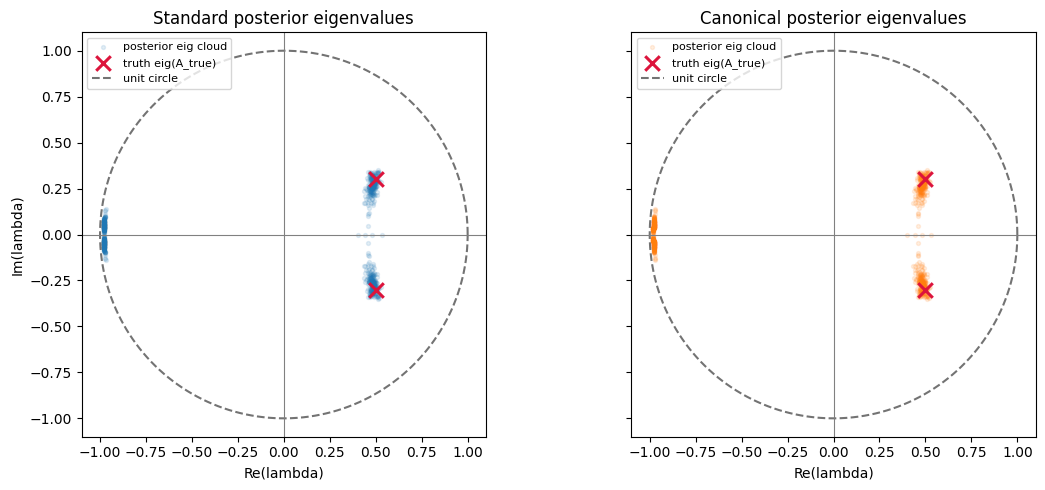

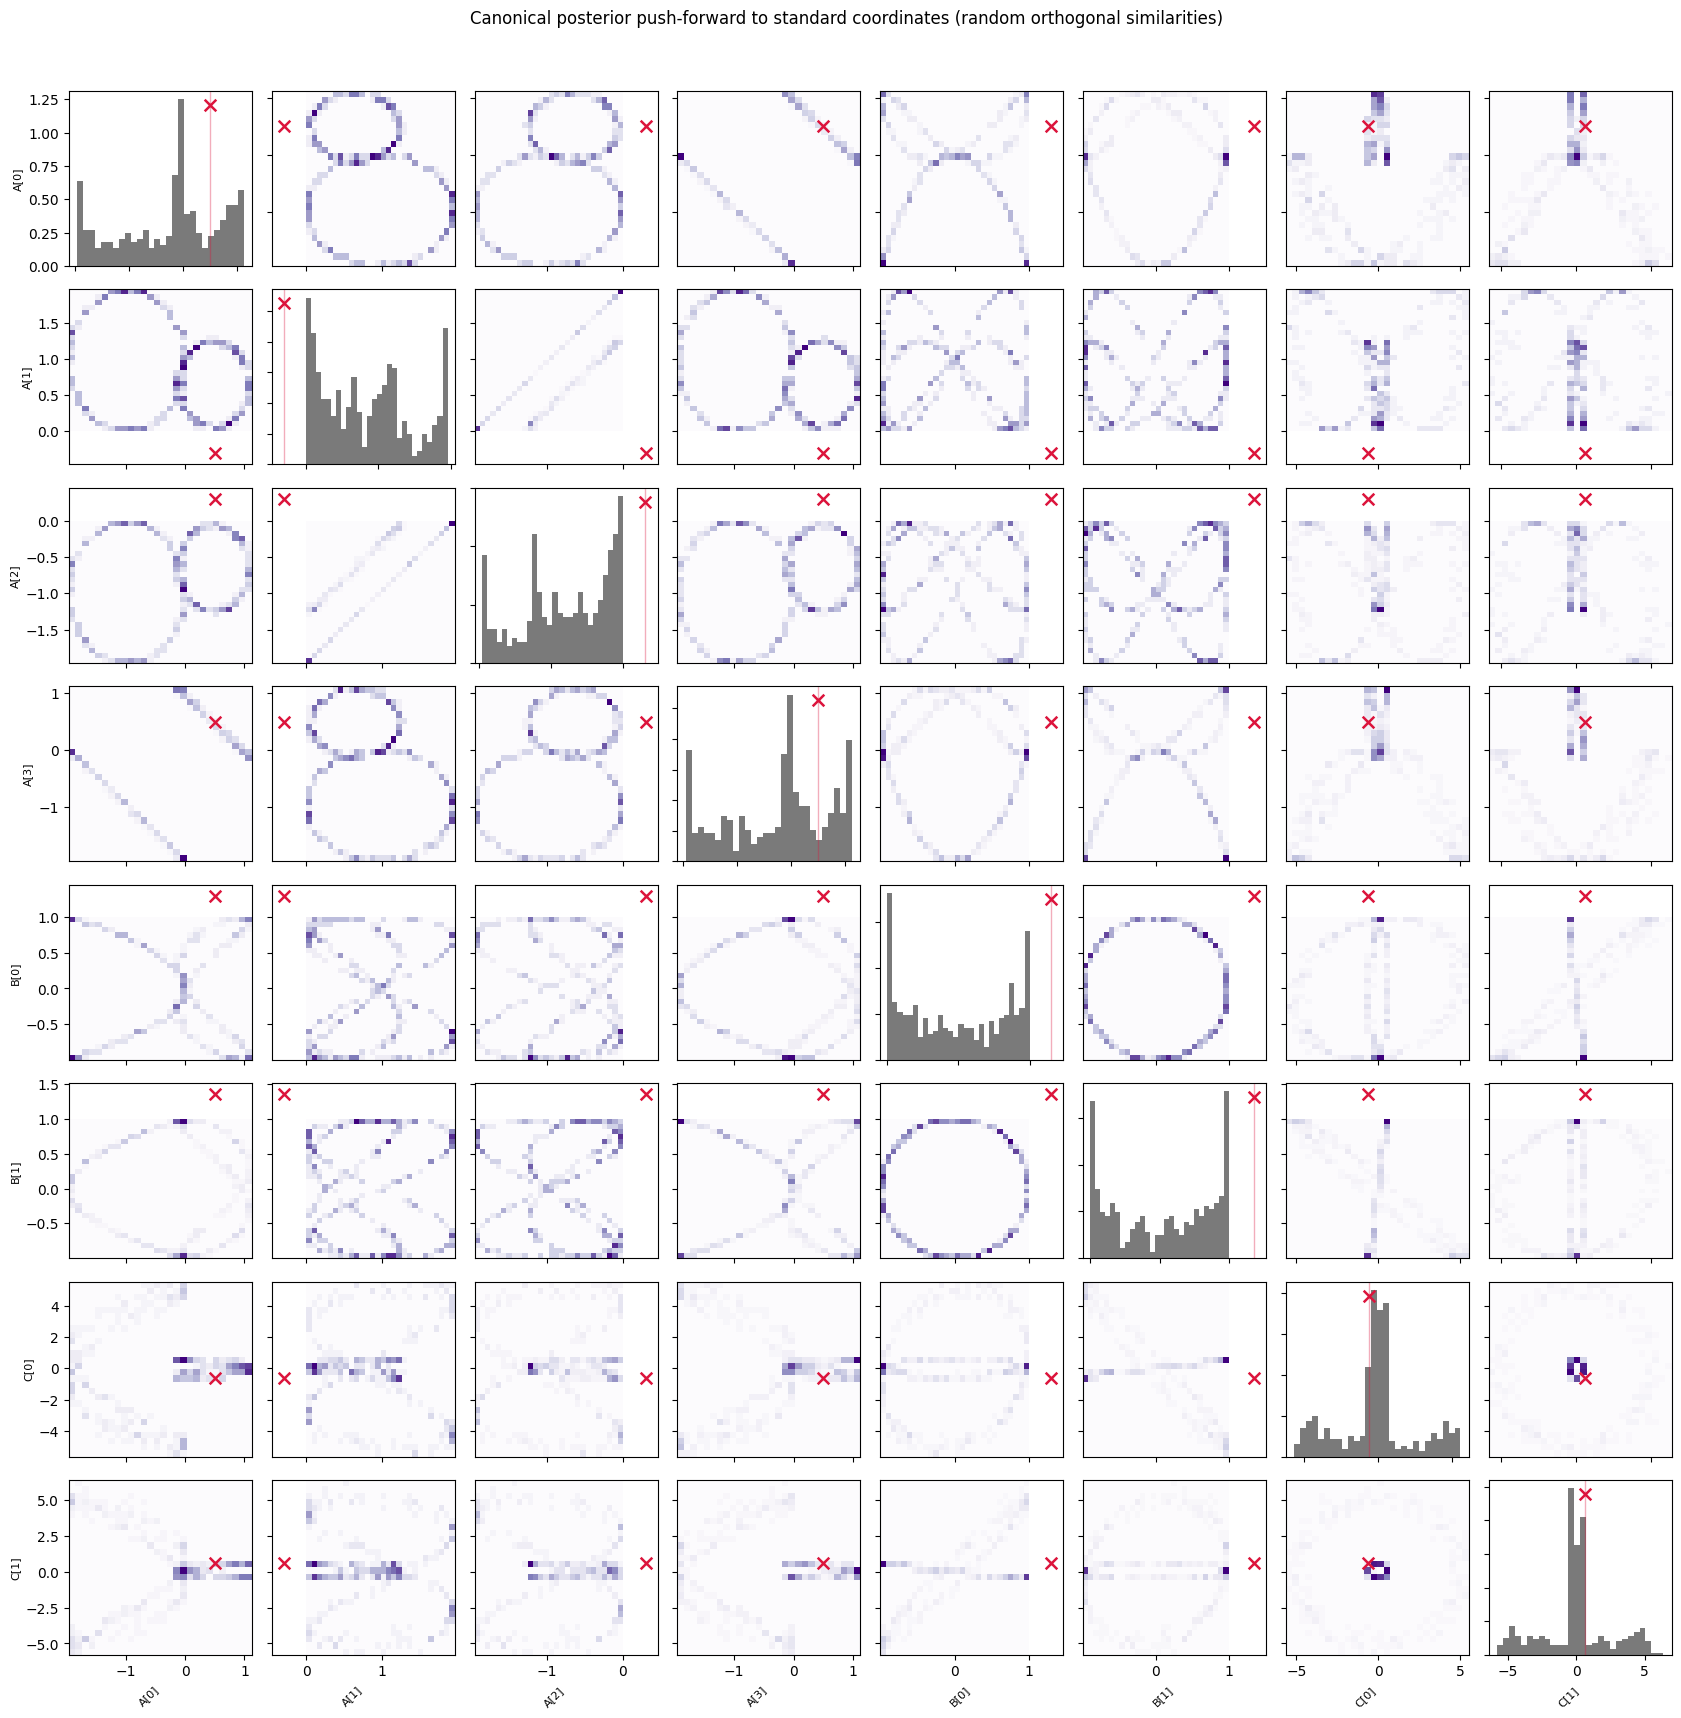

Push-forward sample size: 400
Mean spectral radius of pushed A: 0.7656074931411606


In [10]:
# Canonical plot includes inferred quantities only (no fixed B or canonical A entries).
canonical_keys = ['a0', 'a1', 'C']
canonical_theta, canonical_names = flatten_parameter_block(post_can, keys=canonical_keys)
a0_true = float(np.linalg.det(np.array(A_true)))
a1_true = float(-np.trace(np.array(A_true)))
canonical_true_map = {
    'a0': a0_true,
    'a1': a1_true,
    'C': np.array(C_can_true),
}
canonical_truth_vector = build_true_vector(canonical_names, canonical_true_map, keys=canonical_keys)

plot_full_bivariate_hist(
    canonical_theta,
    canonical_names,
    title='Canonical model: inferred-parameter bivariate histograms (a0, a1, C entries)',
    cmap='Oranges',
    truth_vector=canonical_truth_vector,
)

plot_eigenvalue_posteriors_on_unit_circle(post_can['A'], post_can['A'], A_true)

post_can_push = pushforward_canonical_to_standard(post_can, n_push=1500)

# Visualize pushed-forward canonical posterior in standard coordinates.
push_keys = ['A', 'B', 'C']
push_theta, push_names = flatten_parameter_block(post_can_push, keys=push_keys)
push_truth = build_true_vector(push_names, standard_true_map, keys=push_keys)
plot_full_bivariate_hist(
    push_theta,
    push_names,
    title='Canonical posterior push-forward to standard coordinates (random orthogonal similarities)',
    cmap='Purples',
    truth_vector=push_truth,
)

print('Push-forward sample size:', push_theta.shape[0])
print('Mean spectral radius of pushed A:', float(np.mean(np.max(np.abs(np.linalg.eigvals(post_can_push['A'])), axis=1))))

This run learns all entries in `A, B, C` directly, so it has the most flexible (and potentially least identifiable) parameter geometry.

Use this as the baseline before imposing canonical structure.

In [11]:
# 3A) Standard-form posterior run
print('\n=== Standard-form inference (learn A, B, C directly) ===')
rng, k_std = jr.split(rng, 2)
std_cond = make_conditioned_model(standard_model, y_obs)
mcmc_std, post_std = run_mcmc(std_cond, k_std, 'standard')


=== Standard-form inference (learn A, B, C directly) ===


  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]


                                        mean       std    median      5.0%     95.0%     n_eff     r_hat
                            A[0,0]     -0.05      1.01      0.24     -1.78      0.96      2.24      3.10
                            A[0,1]      0.19      0.58      0.01     -0.56      1.32      3.00      1.75
                            A[1,0]      0.27      1.01     -0.01     -1.11      1.78      2.26      3.12
                            A[1,1]      0.39      0.42      0.40     -0.34      1.03     16.24      1.22
                            B[0,0]     -0.16      0.93     -0.41     -1.34      1.10      3.79      1.52
                            B[1,0]     -0.39      0.68     -0.62     -1.29      0.85      3.23      1.67
                            C[0,0]     -0.48      0.99     -0.12     -2.48      0.47      2.30      3.06
                            C[0,1]     -0.65      1.20     -0.26     -2.99      0.53      2.19      4.06
 f_filtered_states_chol_cov[0,0,0]      0.14      0.77

### 3D) Chain quality diagnostics

Before proceeding with any analysis or plotting we check each chain for signs of pathological
behaviour — most commonly a chain that is **stuck in a local mode** or failed to mix into the
main posterior mass.

**Criterion.**  For each model we extract the per-chain `potential_energy` (= −log p(θ, y),
collected by numpyro's NUTS kernel).  A chain whose mean log-posterior falls more than
`CHAIN_BAD_SIGMA` pooled within-chain standard deviations below the best chain is flagged as
*bad*.  The report below explains the gap in nats and in σ units.

**Effect.**  `post_std` and `post_can` are overwritten with samples drawn only from the
good chains, so all subsequent analysis and plots automatically use the filtered posteriors.

> **Note:** the bivariate-histogram plots in §3A/3B above were produced immediately after each
> MCMC run and therefore still reflect all chains.  Re-executing those cells after this one will
> show the filtered posteriors.

In [12]:
CHAIN_BAD_SIGMA = 2.0  # chains whose mean log-post is >this many σ below the best are flagged


def diagnose_chains(mcmc, name, threshold_sigma=CHAIN_BAD_SIGMA):
    """
    Flag bad chains based on mean log-posterior (= -potential_energy).

    A chain is *bad* if its mean log-posterior is more than `threshold_sigma`
    pooled within-chain standard deviations below the best chain's mean.

    Returns
    -------
    good_mask : np.ndarray of bool, shape (num_chains,)
    """
    extra = mcmc.get_extra_fields(group_by_chain=True)
    pe    = np.array(extra['potential_energy'])   # (n_chains, n_samples)
    lp    = -pe                                    # log-posterior proxy

    mean_lp    = lp.mean(axis=1)                  # (n_chains,)
    std_lp     = lp.std(axis=1)                   # per-chain std
    pooled_std = float(lp.std())
    best_mean  = float(mean_lp.max())
    gap_sigma  = (best_mean - mean_lp) / max(pooled_std, 1e-9)
    good_mask  = gap_sigma <= threshold_sigma

    n_chains = len(mean_lp)
    n_good   = int(good_mask.sum())
    n_bad    = n_chains - n_good

    sep  = '=' * 62
    dash = '-' * 62
    lines = [
        '',
        sep,
        f'  Chain diagnostics — {name}',
        sep,
        f'  threshold : {threshold_sigma}σ  |  pooled σ(log-post) = {pooled_std:.3f}',
        '',
        f'  {"Chain":>5}  {"Mean log-post":>14}  {"Std log-post":>13}  {"Δ best (σ)":>10}  {"Status":>7}',
        f'  {"-"*5}  {"-"*14}  {"-"*13}  {"-"*10}  {"-"*7}',
    ]
    for c in range(n_chains):
        status = 'good' if good_mask[c] else 'BAD'
        lines.append(
            f'  {c:>5}  {mean_lp[c]:>14.2f}  {std_lp[c]:>13.2f}  {gap_sigma[c]:>10.2f}  {status:>7}'
        )
    lines += [
        '',
        f'  Result: {n_good} good, {n_bad} bad out of {n_chains} chains.',
    ]

    if n_bad > 0:
        delta = float(mean_lp[good_mask].mean() - mean_lp[~good_mask].mean())
        delta_s = delta / max(pooled_std, 1e-9)
        lines += [
            '',
            f'  Why bad?  Bad chain(s) have a mean log-posterior {delta:.2f} nats',
            f'  ({delta_s:.1f}σ) lower than the good-chain mean.  This gap is large',
            f'  enough to indicate the chain is stuck in a region of substantially',
            f'  lower posterior probability — likely poor initialisation, slow',
            f'  mixing, or attraction to a minor mode.',
            f'  These chain(s) are excluded from all downstream analysis.',
        ]
    else:
        lines.append('  All chains healthy — no outliers detected.')

    lines.append(sep)
    print('\n'.join(lines))
    return good_mask


def filter_samples_by_chains(mcmc, good_mask):
    """Concatenate samples from good chains only → shape (n_good*n_samples, ...)."""
    chain_samples = mcmc.get_samples(group_by_chain=True)
    good_idx = np.where(np.array(good_mask))[0]
    return {
        k: np.concatenate([v[c] for c in good_idx], axis=0)
        for k, v in chain_samples.items()
    }


# ── run diagnostics ──────────────────────────────────────────────────────────
good_mask_std = diagnose_chains(mcmc_std, 'standard')
good_mask_can = diagnose_chains(mcmc_can, 'canonical')

# ── save pre-filter copies for comparison plots ───────────────────────────────
post_std_all = mcmc_std.get_samples(group_by_chain=False)
post_can_all = mcmc_can.get_samples(group_by_chain=False)

# ── override posterior dicts with good-chains-only samples ───────────────────
post_std = filter_samples_by_chains(mcmc_std, good_mask_std)
post_can = filter_samples_by_chains(mcmc_can, good_mask_can)

print(
    f'\nFiltered posteriors ready:\n'
    f'  post_std : {list(post_std.values())[0].shape[0]} samples '
    f'({int(good_mask_std.sum())}/{len(good_mask_std)} chains)\n'
    f'  post_can : {list(post_can.values())[0].shape[0]} samples '
    f'({int(good_mask_can.sum())}/{len(good_mask_can)} chains)'
)


  Chain diagnostics — standard
  threshold : 2.0σ  |  pooled σ(log-post) = 134.715

  Chain   Mean log-post   Std log-post  Δ best (σ)   Status
  -----  --------------  -------------  ----------  -------
      0           20.39           1.89        0.01     good
      1         -189.12         198.88        1.56     good
      2           20.70           2.13        0.00     good
      3           21.10           2.10        0.00     good

  Result: 4 good, 0 bad out of 4 chains.
  All chains healthy — no outliers detected.

  Chain diagnostics — canonical
  threshold : 2.0σ  |  pooled σ(log-post) = 256.256

  Chain   Mean log-post   Std log-post  Δ best (σ)   Status
  -----  --------------  -------------  ----------  -------
      0         -488.04           1.21        2.00      BAD
      1         -487.56           1.31        2.00     good
      2           24.84           1.41        0.00     good
      3           24.57           1.88        0.00     good

  Result: 3 good, 1 b

Standard: all chains healthy — pre- and post-filter distributions are identical; skipping duplicate plot.


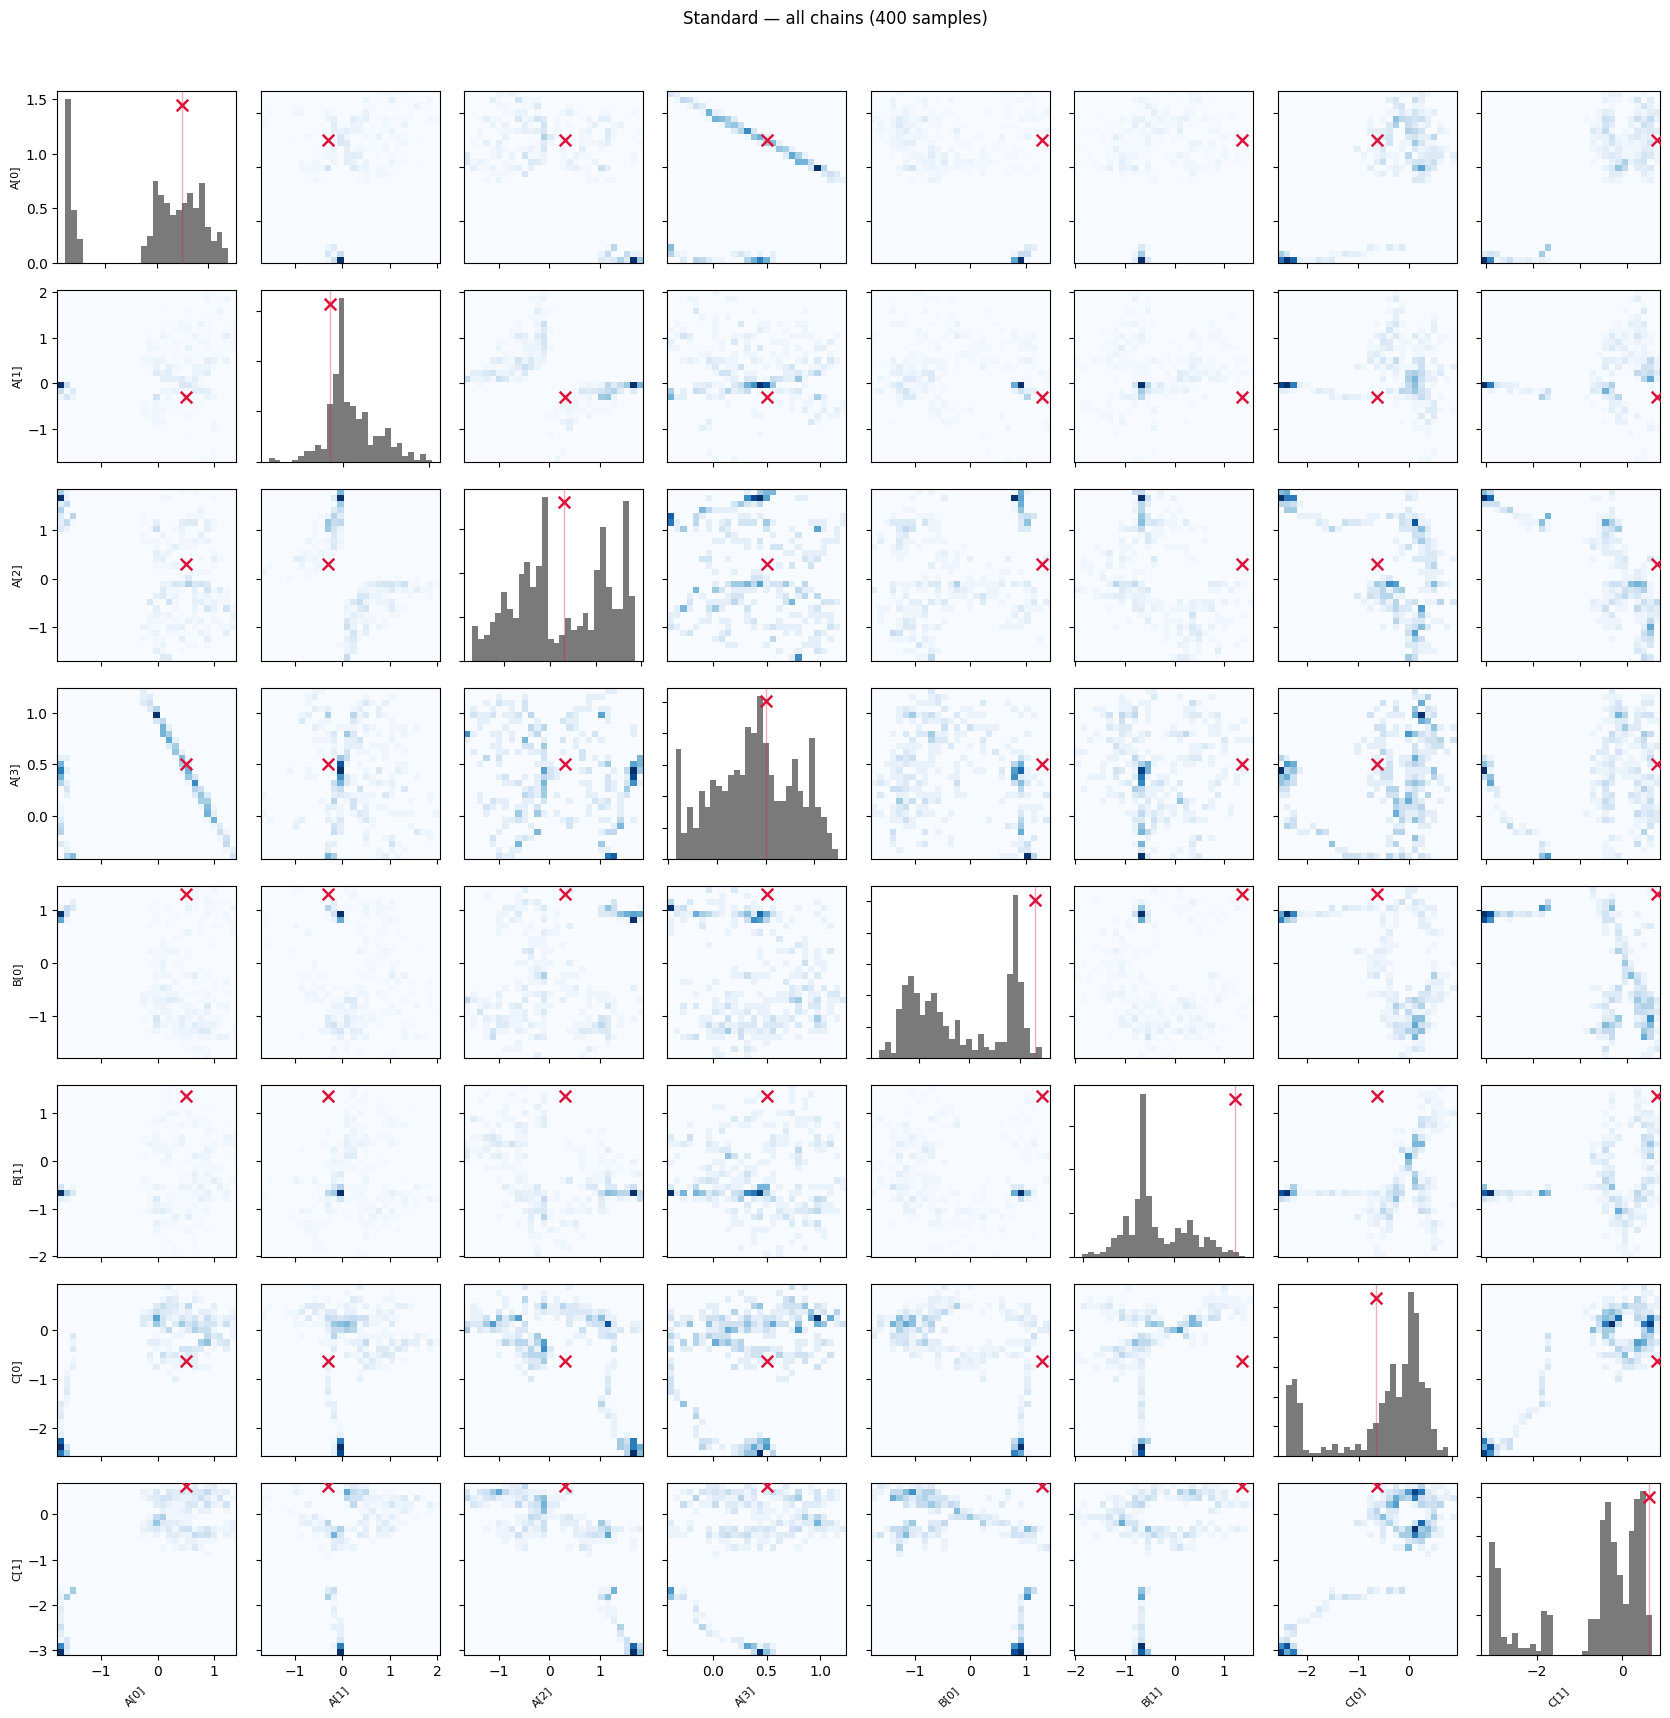

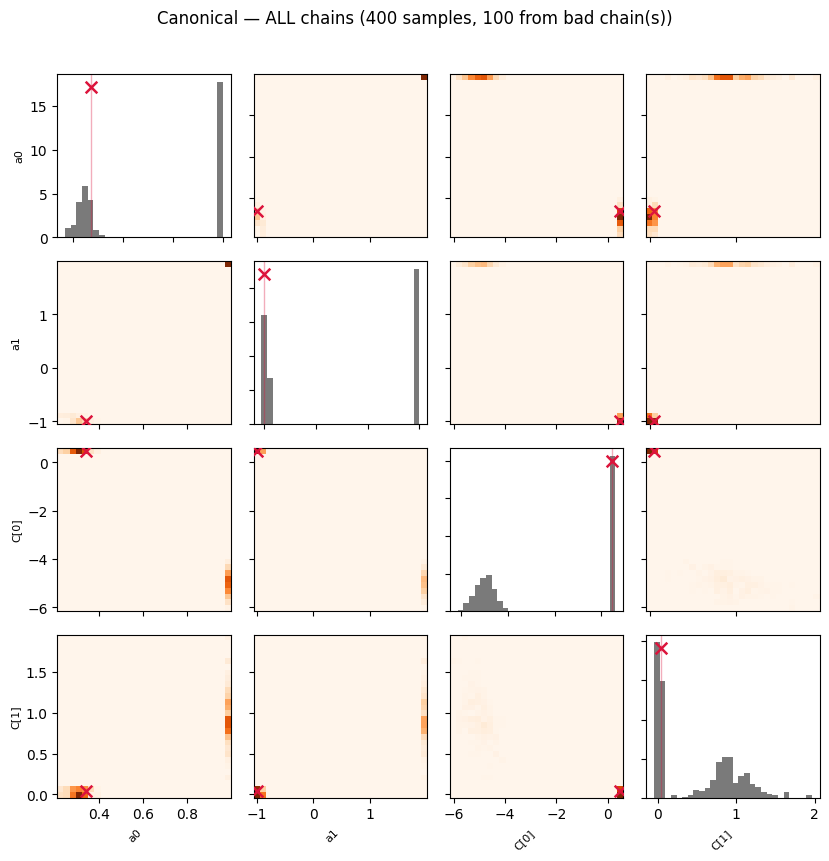

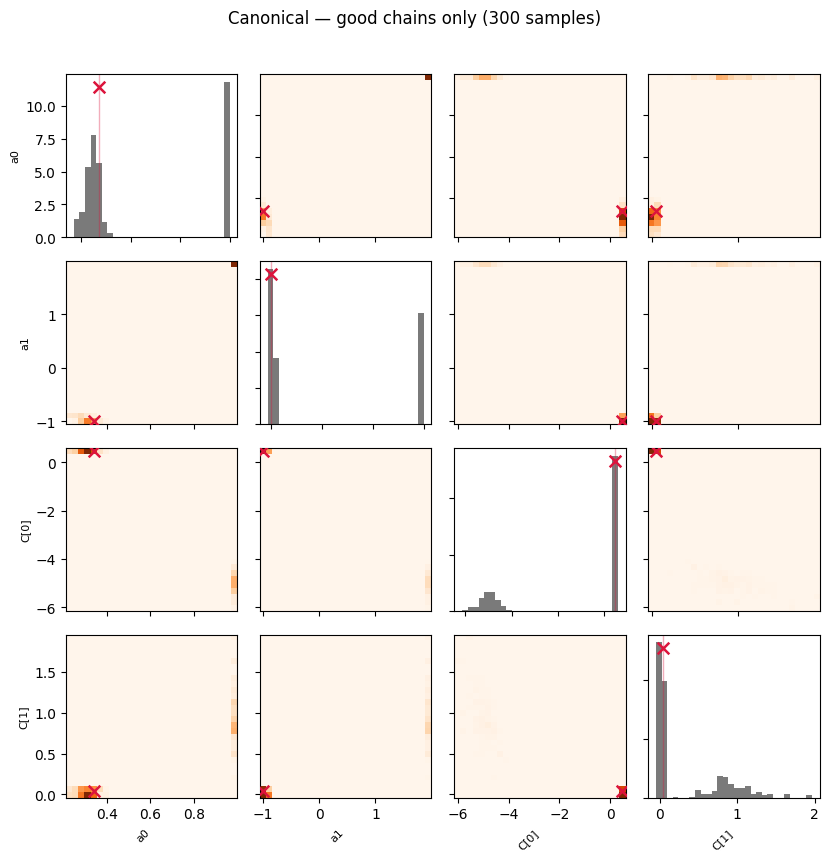

In [13]:
# ── pre/post chain-filter bivariate histogram comparison ─────────────────────
a0_true = float(np.linalg.det(np.array(A_true)))
a1_true = float(-np.trace(np.array(A_true)))
canonical_true_map_local = {'a0': a0_true, 'a1': a1_true, 'C': np.array(C_can_true)}

_pairs = [
    # (label_prefix,  samples_all,  samples_filtered,  keys,         true_map,         cmap)
    ('Standard',  post_std_all, post_std, ['A', 'B', 'C'], standard_true_map,      'Blues'),
    ('Canonical', post_can_all, post_can, ['a0', 'a1', 'C'], canonical_true_map_local, 'Oranges'),
]

for label, s_all, s_filt, keys, true_map, cmap in _pairs:
    theta_all,  names_all  = flatten_parameter_block(s_all,  keys)
    theta_filt, names_filt = flatten_parameter_block(s_filt, keys)
    truth = build_true_vector(names_all, true_map, keys)

    n_all  = theta_all.shape[0]
    n_filt = theta_filt.shape[0]
    n_bad  = n_all - n_filt

    if n_bad == 0:
        print(f'{label}: all chains healthy — pre- and post-filter distributions are identical; skipping duplicate plot.')
        plot_full_bivariate_hist(
            theta_all, names_all,
            title=f'{label} — all chains ({n_all} samples)',
            cmap=cmap, truth_vector=truth,
        )
    else:
        plot_full_bivariate_hist(
            theta_all, names_all,
            title=f'{label} — ALL chains ({n_all} samples, {n_bad} from bad chain(s))',
            cmap=cmap, truth_vector=truth,
        )
        plot_full_bivariate_hist(
            theta_filt, names_filt,
            title=f'{label} — good chains only ({n_filt} samples)',
            cmap=cmap, truth_vector=truth,
        )

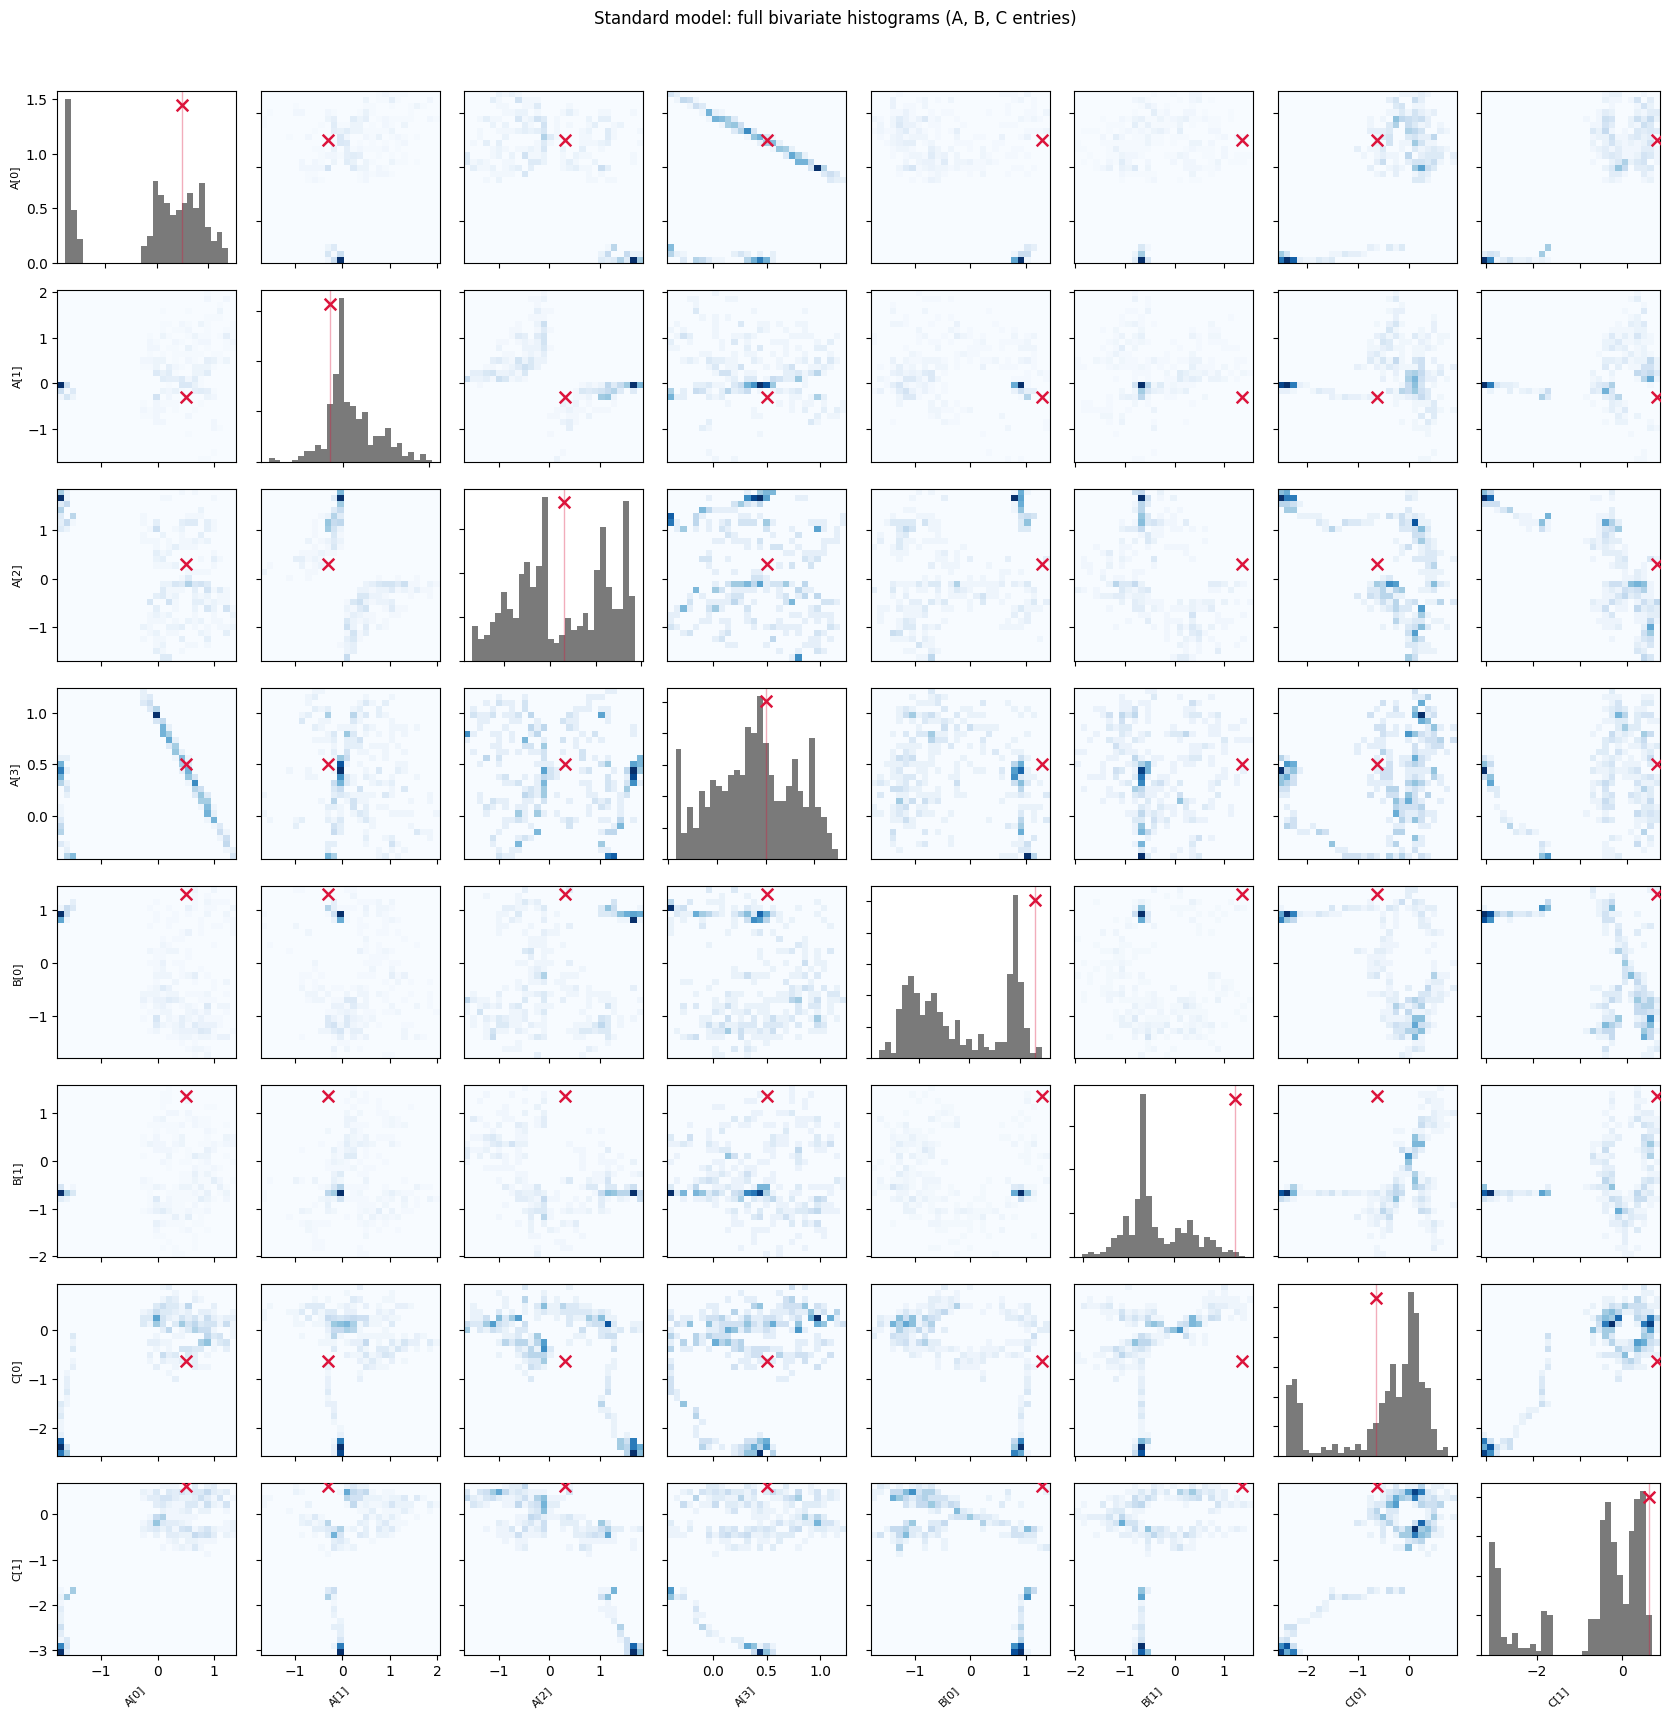

In [14]:
standard_keys = ['A', 'B', 'C']
standard_theta, standard_names = flatten_parameter_block(post_std, keys=standard_keys)
standard_truth_vector = build_true_vector(standard_names, standard_true_map, keys=standard_keys)

plot_full_bivariate_hist(
    standard_theta,
    standard_names,
    title='Standard model: full bivariate histograms (A, B, C entries)',
    cmap='Blues',
    truth_vector=standard_truth_vector,
)

### 3C) Side-by-side posterior diagnostics

Below we compare stability mass and posterior summaries for each model against the same ground-truth parameters, then visualize pairwise posterior structure for:

- **Standard:** `A, B, C`
- **Canonical:** inferred-only block `a0, a1, C`

In [15]:
def spectral_radius_batch(A_samples):
    eigvals = jax.vmap(jnp.linalg.eigvals)(A_samples)
    return jnp.max(jnp.abs(eigvals), axis=1)


def summarize_param(name, samples, true_value=None):
    arr = np.array(samples)
    q05, q50, q95 = np.quantile(arr, [0.05, 0.5, 0.95], axis=0)
    print(f'--- {name} ---')
    print('median:\n', q50)
    print('90% interval low:\n', q05)
    print('90% interval high:\n', q95)
    if true_value is not None:
        print('true:\n', np.array(true_value))


A_std = post_std['A']
A_can = post_can['A']
B_std = post_std['B']
B_can = post_can.get('B', jnp.tile(jnp.array([[0.0], [1.0]])[None, :, :], (A_can.shape[0], 1, 1)))
C_std = post_std['C']
C_can = post_can['C']

rho_std = spectral_radius_batch(A_std)
rho_can = spectral_radius_batch(A_can)

stable_std = np.mean(np.array(rho_std < 1.0))
stable_can = np.mean(np.array(rho_can < 1.0))

print(f'Stable posterior mass (standard): {stable_std:.3f}')
print(f'Stable posterior mass (canonical): {stable_can:.3f}')

summarize_param('A (standard)', A_std, A_true)
summarize_param('A (canonical)', A_can, A_true)
summarize_param('B (standard)', B_std, B_true)
summarize_param('B (canonical)', B_can, B_true)
summarize_param('C (standard)', C_std, C_true)
summarize_param('C (canonical)', C_can, C_can_true)
print('Known sigma_state:', float(sigma_state_true))
print('Known sigma_obs:', float(sigma_obs_true))

Stable posterior mass (standard): 0.777
Stable posterior mass (canonical): 1.000
--- A (standard) ---
median:
 [[ 0.24386413  0.00911725]
 [-0.00906038  0.39969173]]
90% interval low:
 [[-1.74398024 -0.58252504]
 [-1.28098211 -0.36856809]]
90% interval high:
 [[1.14263784 1.29283813]
 [1.7065609  1.01918722]]
true:
 [[ 0.5 -0.3]
 [ 0.3  0.5]]
--- A (canonical) ---
median:
 [[ 0.          1.        ]
 [-0.32901219  0.94058663]]
90% interval low:
 [[ 0.          0.98032012]
 [-0.97967988 -1.95864128]]
90% interval high:
 [[ 0.          1.        ]
 [-0.24748333  1.01410099]]
true:
 [[ 0.5 -0.3]
 [ 0.3  0.5]]
--- B (standard) ---
median:
 [[-0.40863422]
 [-0.61740911]]
90% interval low:
 [[-1.37327631]
 [-1.28418886]]
90% interval high:
 [[1.07027242]
 [0.87845792]]
true:
 [[1.2956359]
 [1.3550105]]
--- B (canonical) ---
median:
 [[0.]
 [1.]]
90% interval low:
 [[0.]
 [1.]]
90% interval high:
 [[0.]
 [1.]]
true:
 [[1.2956359]
 [1.3550105]]
--- C (standard) ---
median:
 [[-0.12017309 -0.26

## 4) Predictive performance and posterior predictive intervals

We compare posterior predictive trajectories for observed `y_t` under both parameterizations.

For each model we:

- draw parameter samples from the posterior,
- simulate forward under the observed controls,
- compute posterior predictive median and 90% intervals,
- report RMSE of posterior predictive median against observed data.

RMSE (standard median predictor):  0.2210
RMSE (canonical median predictor): 0.2404


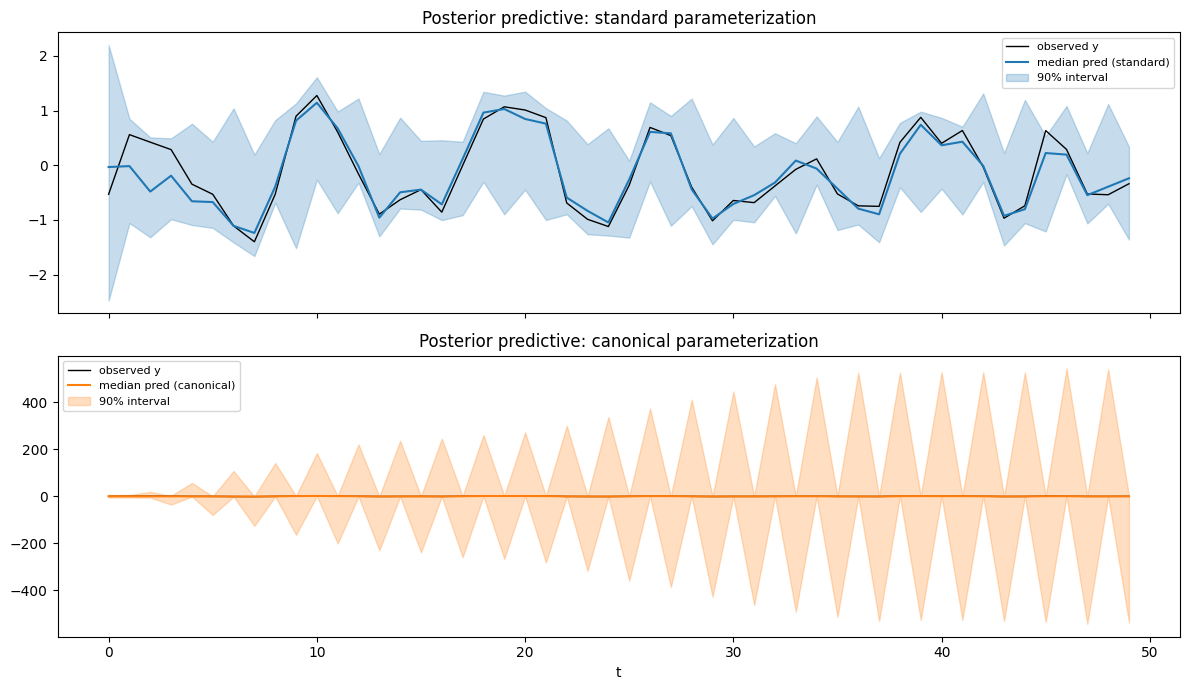

In [16]:
def subset_samples(samples, n_keep=300):
    n = list(samples.values())[0].shape[0]
    idx = np.linspace(0, n - 1, min(n, n_keep), dtype=int)
    keep = [
        'A',
        'B',
        'C',
        'a0',
        'a1',
        'tri_u',
        'tri_v',
        'lambda1_real',
        'lambda1_imag',
        'lambda2_real',
        'lambda2_imag',
    ]
    return {k: v[idx] for k, v in samples.items() if k in keep}


def posterior_predictive(base_model, posterior_samples, key):
    pred = Predictive(
        base_model,
        posterior_samples=posterior_samples,
        exclude_deterministic=False,
    )
    with DiscreteTimeSimulator():
        out = pred(key, obs_times=obs_times, ctrl_times=ctrl_times, ctrl_values=ctrl_values)
    return out['observations'][..., 0]


rng, kpp_std, kpp_can = jr.split(rng, 3)
post_std_small = subset_samples(post_std, n_keep=300)
post_can_small = subset_samples(post_can, n_keep=300)

yhat_std = posterior_predictive(standard_model, post_std_small, kpp_std)
yhat_can = posterior_predictive(canonical_model, post_can_small, kpp_can)

def summarize_pred(yhat, y):
    lo = np.quantile(yhat, 0.05, axis=0)
    md = np.quantile(yhat, 0.50, axis=0)
    hi = np.quantile(yhat, 0.95, axis=0)
    rmse = np.sqrt(np.mean((md - np.array(y[:, 0])) ** 2))
    return lo, md, hi, rmse

lo_s, md_s, hi_s, rmse_s = summarize_pred(np.array(yhat_std), y_obs)
lo_c, md_c, hi_c, rmse_c = summarize_pred(np.array(yhat_can), y_obs)

print(f'RMSE (standard median predictor):  {rmse_s:.4f}')
print(f'RMSE (canonical median predictor): {rmse_c:.4f}')

ix = np.arange(T)
fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axs[0].plot(ix, np.array(y_obs[:, 0]), color='k', lw=1, label='observed y')
axs[0].plot(ix, md_s, color='C0', lw=1.5, label='median pred (standard)')
axs[0].fill_between(ix, lo_s, hi_s, color='C0', alpha=0.25, label='90% interval')
axs[0].set_title('Posterior predictive: standard parameterization')
axs[0].legend(fontsize=8)

axs[1].plot(ix, np.array(y_obs[:, 0]), color='k', lw=1, label='observed y')
axs[1].plot(ix, md_c, color='C1', lw=1.5, label='median pred (canonical)')
axs[1].fill_between(ix, lo_c, hi_c, color='C1', alpha=0.25, label='90% interval')
axs[1].set_title('Posterior predictive: canonical parameterization')
axs[1].set_xlabel('t')
axs[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [17]:
# Posterior eigenvalue geometry + push-forward canonical -> standard via random orthogonal similarities.





## 5) Discussion

### Identifiability and geometry

- The standard parameterization is often weakly identified under partial observation (`d_y < d_x`), creating elongated or multi-modal posterior geometry in raw matrix entries.
- Canonical coordinates reduce equivalent representations by constraining `A` and fixing `B = [[0], [1]]`.
- In this setup, the canonical model learns only `a0, a1, C`, which removes extra degrees of freedom in `B`.

### Stability behavior

- Compare posterior mass with spectral radius `< 1`.
- Canonical priors can place stronger and more interpretable mass over stable dynamics.

### Predictive behavior

- Even when raw parameters are hard to recover, one-step/marginal predictive fit may still be strong.
- This is why predictive intervals and RMSE are reported alongside parameter posteriors.

### Notes

- This notebook keeps everything in basic `dynestyx` (`LTI_discrete`, `Filter(KFConfig())`, `DiscreteTimeSimulator`).
- The canonical model places a uniform prior directly on `(a0, a1)` in the Schur stability triangle.
- Full bivariate posterior histograms are shown for each model; the standard model has more parameters than the canonical one.
- Eigenvalue summaries are reported via the roots of `z^2 + a1 z + a0 = 0`.

Reference on canonical Bayesian identification: https://arxiv.org/abs/2507.11535